In [1]:
from IPython.display import HTML
HTML('''<style>.jp-Cell-inputWrapper, .input { margin-top: 0.5em; }</style>''')

# Notebook 02 — Exploratory Data Analysis
## ENGG2112 Project MODR

This notebook explores the master cross-section dataset (`master_counties.csv`, 141 areas across NY/PA/CT/DE) to:

1. Validate the outbreak label is sensible
2. Surface distributions and outliers
3. Identify multicollinearity (informs feature selection)
4. Map feature-outcome relationships
5. Investigate counterintuitive findings (per-state correlations, data gaps, temporal trends)
6. Generate insights that feed into Notebook 03 (Feature Selection)

### Inputs
- `data/processed/master_counties.csv` — 141 areas × 38 columns (primary cross-section)
- `data/processed/master_panel.csv` — 1,144 obs × 38 columns (sensitivity panel)

### Approach
Report-style: each section has a question, a chart, and a written interpretation. The deep-dive section (12) addresses counterintuitive findings surfaced during analysis.

### Reference
- Methodology citations: `REFERENCES.md`
- Column definitions: `docs/data_dictionary.md`
- Decision history: `PROJECT_JOURNAL.md`

## 1. Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Paths
PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.size': 11,
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_style('whitegrid')

STATE_COLOURS = {'NY': '#2E5C9A', 'PA': '#D7263D', 'CT': '#4ECDC4', 'DE': '#F18F01'}

master = pd.read_csv(PROCESSED_DIR / 'master_counties.csv', dtype={'fips': str, 'state_fips': str})
panel = pd.read_csv(PROCESSED_DIR / 'master_panel.csv', dtype={'fips': str, 'state_fips': str})

print(f'Cross-section: {master.shape}')
print(f'Panel:         {panel.shape}')
print(f'\nStates: {master["state"].value_counts().to_dict()}')

FEATURE_COLS = [
    'pop_density_per_sqmi', 'median_age', 'pct_elderly',
    'avg_household_size',
    'median_income', 'poverty_rate', 'unemployment_rate',
    'public_transport_pct',
    'pct_bachelors_plus',
    'pct_non_white', 'pct_foreign_born'
]
print(f'\nFeatures for analysis: {len(FEATURE_COLS)}')

Cross-section: (141, 38)
Panel:         (1144, 38)

States: {'PA': 67, 'NY': 62, 'CT': 9, 'DE': 3}

Features for analysis: 11


---

## 2. Dataset Overview

In [3]:
print(master[['state', 'fips', 'flu_rate_per_100k', 'outbreak'] + FEATURE_COLS].describe(include='all').round(2).T)

                      count unique    top freq      mean       std      min  \
state                   141      4     PA   67       NaN       NaN      NaN   
fips                    141    141  36001    1       NaN       NaN      NaN   
flu_rate_per_100k     141.0    NaN    NaN  NaN   1693.99    860.87    215.5   
outbreak              141.0    NaN    NaN  NaN      0.26      0.44      0.0   
pop_density_per_sqmi  141.0    NaN    NaN  NaN   1697.16   7697.64     2.96   
median_age            141.0    NaN    NaN  NaN     42.72      3.83     32.6   
pct_elderly           141.0    NaN    NaN  NaN     19.98      2.95    13.28   
avg_household_size    141.0    NaN    NaN  NaN      2.43      0.17     2.03   
median_income         141.0    NaN    NaN  NaN  71515.67  16174.35  46186.0   
poverty_rate          141.0    NaN    NaN  NaN     11.62      3.08     5.31   
unemployment_rate     141.0    NaN    NaN  NaN      5.29      1.25     2.18   
public_transport_pct  141.0    NaN    NaN  NaN      

### Per-state summary

In [4]:
per_state = master.groupby('state').agg(
    n_areas=('fips', 'count'),
    season=('season', 'first'),
    pop_min=('pop_total', 'min'),
    pop_max=('pop_total', 'max'),
    flu_rate_median=('flu_rate_per_100k', 'median'),
    flu_rate_max=('flu_rate_per_100k', 'max'),
    outbreak_count=('outbreak', 'sum'),
).round(0)
print(per_state.to_string())

       n_areas     season  pop_min  pop_max  flu_rate_median  flu_rate_max  outbreak_count
state                                                                                     
CT           9  2024-2025    95687   977165           1436.0        1772.0               3
DE           3  2024-2025   182400   570567           2740.0        3410.0               1
NY          62  2024-2025     5090  2679620           2150.0        4332.0              16
PA          67  2025-2026     4536  1593208            972.0        3006.0              17


---

## 3. Outcome Distribution — `flu_rate_per_100k`

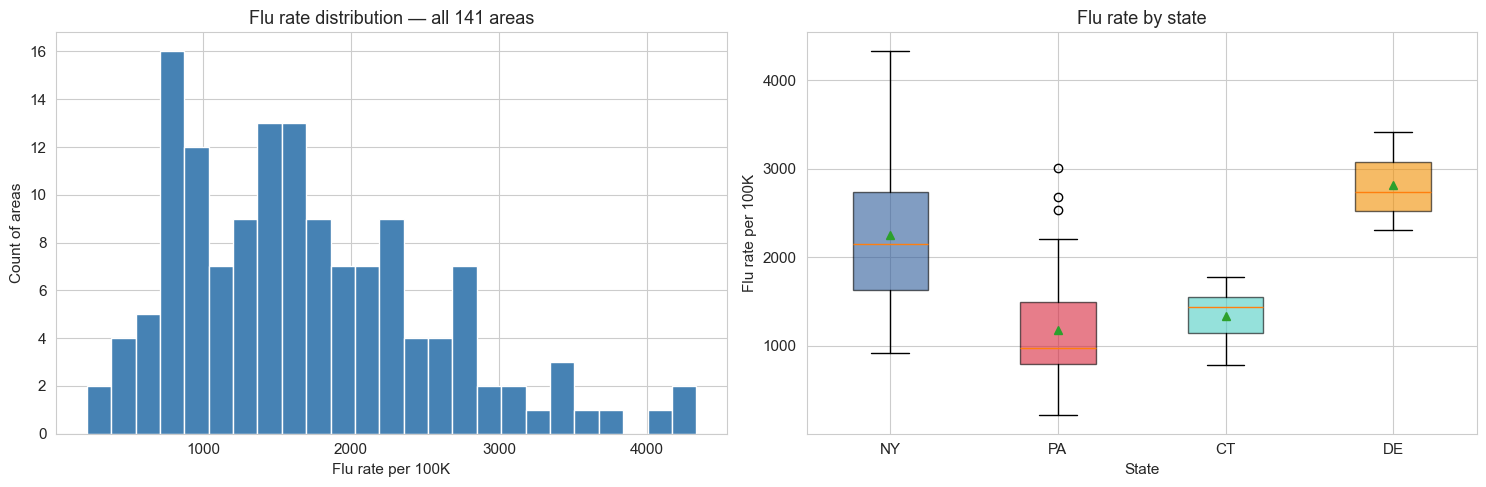

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.hist(master['flu_rate_per_100k'], bins=25, color='steelblue', edgecolor='white')
ax.set_xlabel('Flu rate per 100K')
ax.set_ylabel('Count of areas')
ax.set_title('Flu rate distribution — all 141 areas')

ax = axes[1]
state_order = ['NY', 'PA', 'CT', 'DE']
data_by_state = [master[master['state'] == s]['flu_rate_per_100k'].values for s in state_order]
bp = ax.boxplot(data_by_state, tick_labels=state_order, patch_artist=True, showmeans=True)
for patch, st in zip(bp['boxes'], state_order):
    patch.set_facecolor(STATE_COLOURS[st])
    patch.set_alpha(0.6)
ax.set_xlabel('State')
ax.set_ylabel('Flu rate per 100K')
ax.set_title('Flu rate by state')

plt.tight_layout()
plt.show()

**Interpretation**

State-level differences are large: PA has lower per-capita flu rates than NY/CT/DE. This is mostly a *surveillance* difference (PA reports cumulative cases through April; NY reports completed lab counts). It is **not** that Pennsylvanians get less flu.

This is exactly why we use **within-state** outbreak labelling rather than pooled labelling — it sidesteps the cross-state reporting differences.

---

## 4. Outbreak Label Validation

In [6]:
print('Outbreak threshold per state (75th percentile of flu_rate_per_100k):')
print('-' * 60)
for state in ['NY', 'PA', 'CT', 'DE']:
    sub = master[master['state'] == state]
    threshold = sub['flu_rate_per_100k'].quantile(0.75)
    n_outbreak = sub['outbreak'].sum()
    pct = n_outbreak / len(sub) * 100
    print(f'  {state}: threshold={threshold:>7.0f}/100K, outbreak n={n_outbreak}/{len(sub)} ({pct:.0f}%)')

print(f'\nOverall outbreak rate: {master["outbreak"].mean():.1%}')

Outbreak threshold per state (75th percentile of flu_rate_per_100k):
------------------------------------------------------------
  NY: threshold=   2734/100K, outbreak n=16/62 (26%)
  PA: threshold=   1493/100K, outbreak n=17/67 (25%)
  CT: threshold=   1549/100K, outbreak n=3/9 (33%)
  DE: threshold=   3075/100K, outbreak n=1/3 (33%)

Overall outbreak rate: 26.2%


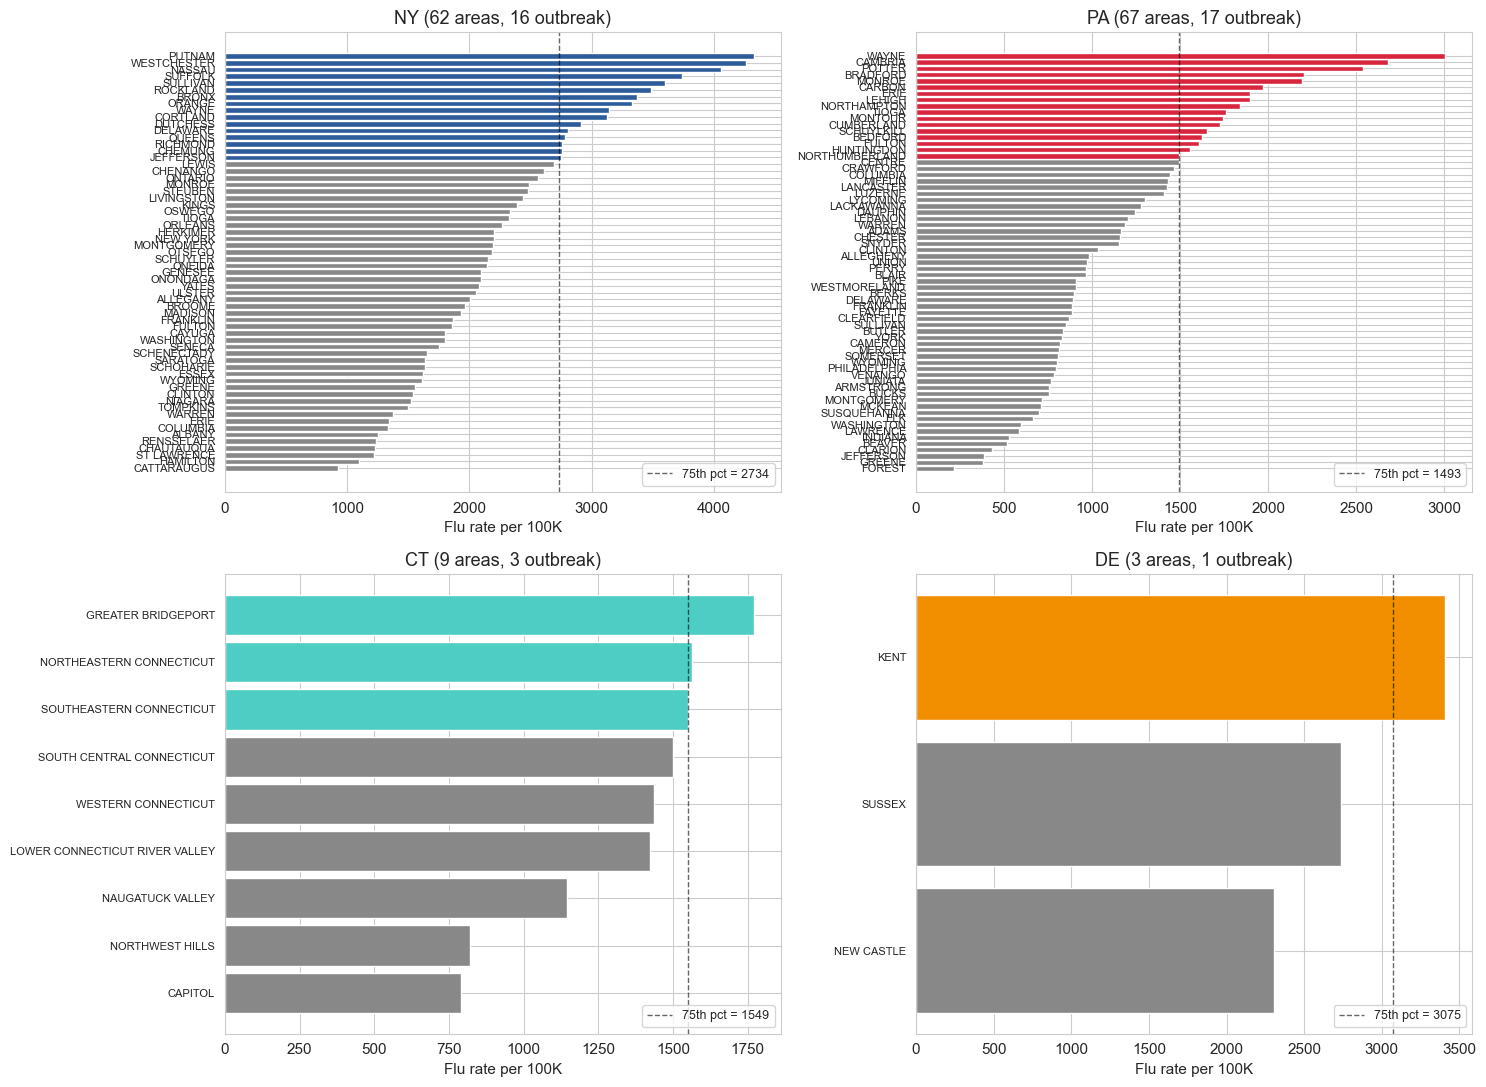

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.flatten()
state_order = ['NY', 'PA', 'CT', 'DE']

for i, state in enumerate(state_order):
    ax = axes[i]
    sub = master[master['state'] == state].sort_values('flu_rate_per_100k')
    colors = sub['outbreak'].map({0: '#888888', 1: STATE_COLOURS[state]})
    ax.barh(range(len(sub)), sub['flu_rate_per_100k'], color=colors, edgecolor='white', height=0.85)
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(sub['county'], fontsize=8)
    threshold = sub['flu_rate_per_100k'].quantile(0.75)
    ax.axvline(threshold, color='black', linestyle='--', linewidth=1, alpha=0.6, 
               label=f'75th pct = {threshold:.0f}')
    ax.set_xlabel('Flu rate per 100K')
    ax.set_title(f'{state} ({len(sub)} areas, {sub["outbreak"].sum()} outbreak)')
    ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

**Interpretation**

Per-state outbreak labels look sensible:
- **NY**: 16/62 (26%) — top counties cluster in NYC area + downstate suburbs
- **PA**: 17/67 (25%) — mix of urban (Philadelphia) and rural counties
- **CT**: 3/9 (33%) — slight ceiling because 9 × 0.25 = 2.25 rounds up
- **DE**: 1/3 (33%) — same ceiling effect with only 3 areas

CT and DE ceiling effects are unavoidable with such small state sizes. We'll be cautious about over-interpreting individual coefficients for these states.

---

## 5. Feature Distributions

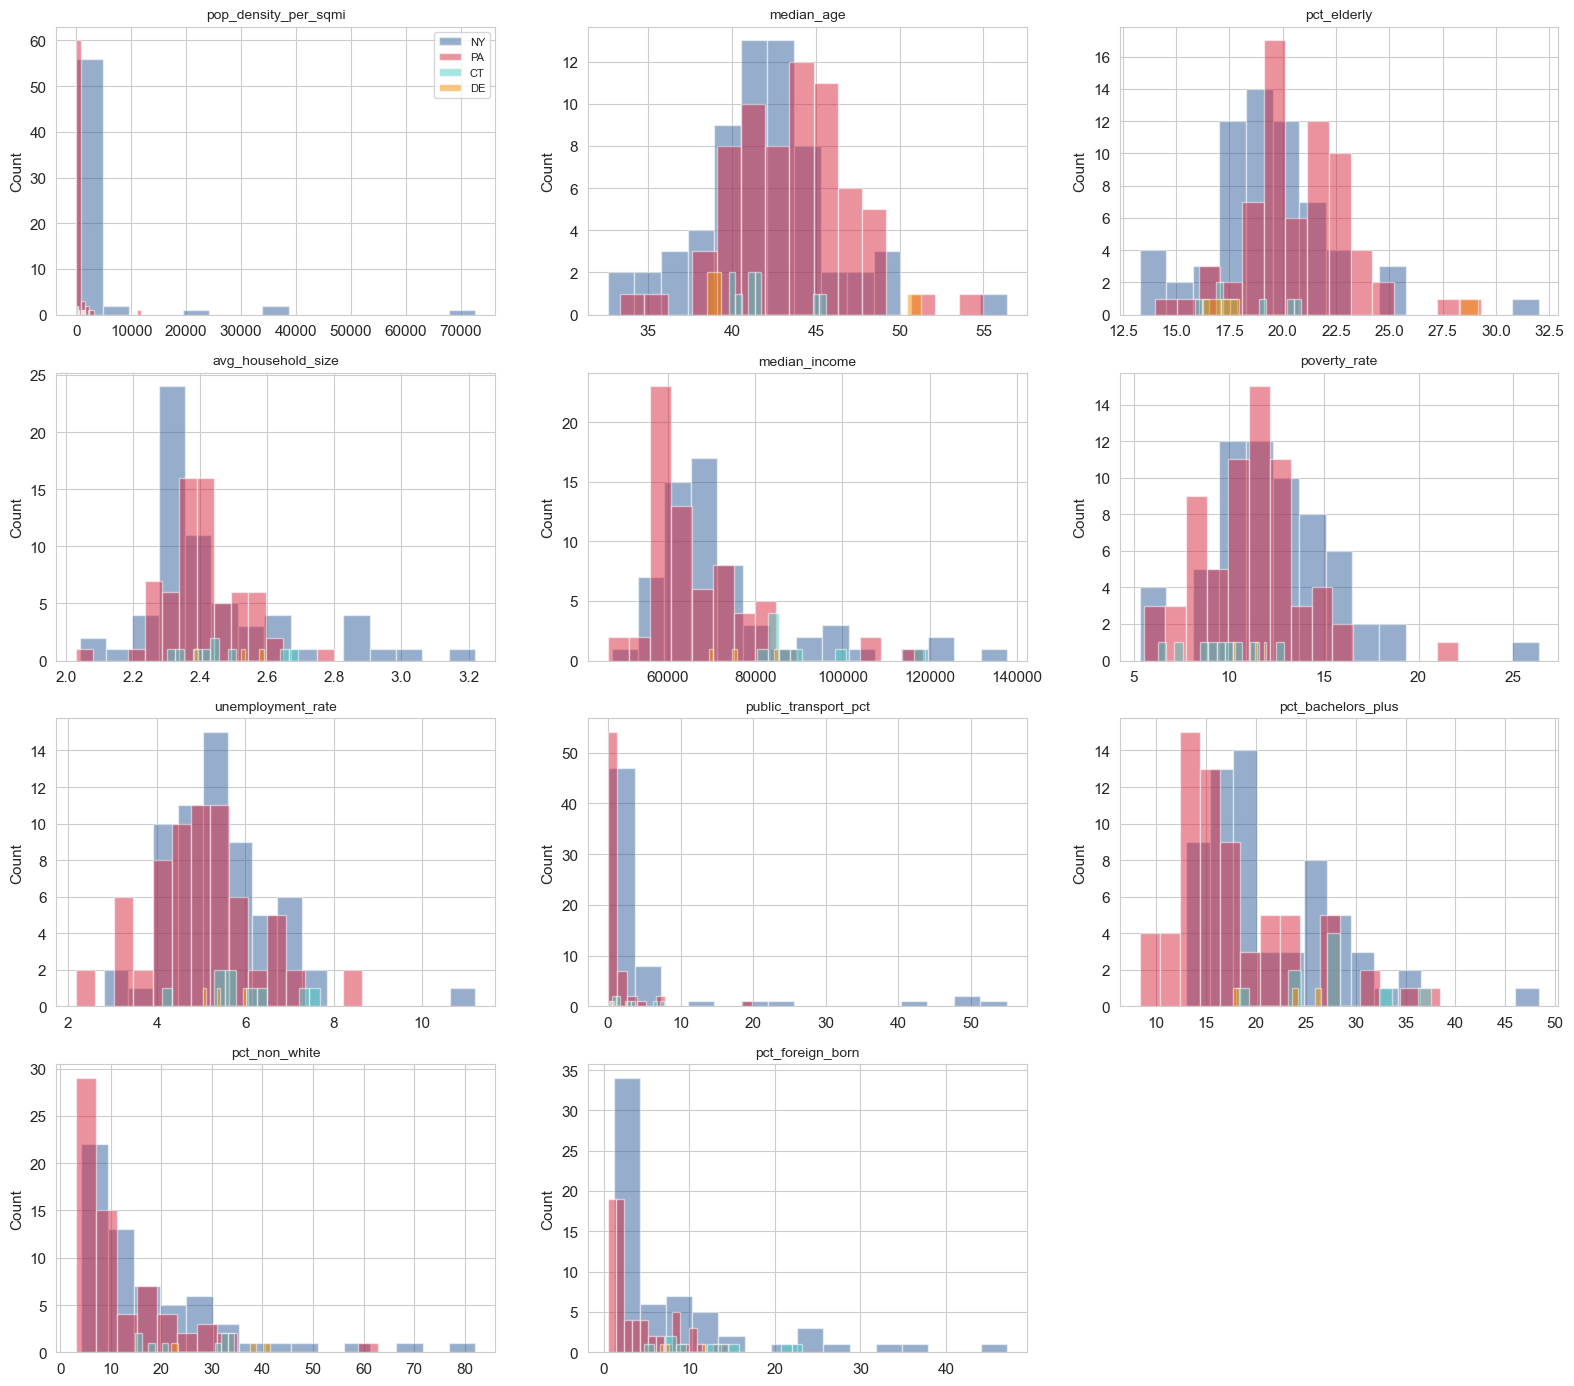

In [8]:
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, feat in enumerate(FEATURE_COLS):
    ax = axes[i]
    for state in ['NY', 'PA', 'CT', 'DE']:
        sub = master[master['state'] == state][feat].dropna()
        ax.hist(sub, bins=15, alpha=0.5, label=state, color=STATE_COLOURS[state], edgecolor='white')
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    if i == 0:
        ax.legend(fontsize=8, loc='upper right')

for j in range(len(FEATURE_COLS), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

**Interpretation**

- **Population density** is heavily right-skewed — driven by NYC boroughs (Manhattan ~71K/sq mi). Will likely benefit from log-transform.
- **% elderly** is similar across states (~17–22%) — well-distributed feature.
- **Median income** clusters by state (CT highest, PA most spread).
- **Public transport %** is dominated by NY (Manhattan ~50%, others mostly <5%) — high-leverage but NY-specific.
- **% non-white** has bimodal distribution — most counties >70% white, urban centres much more diverse.

---

## 6. Feature-Outcome Relationships

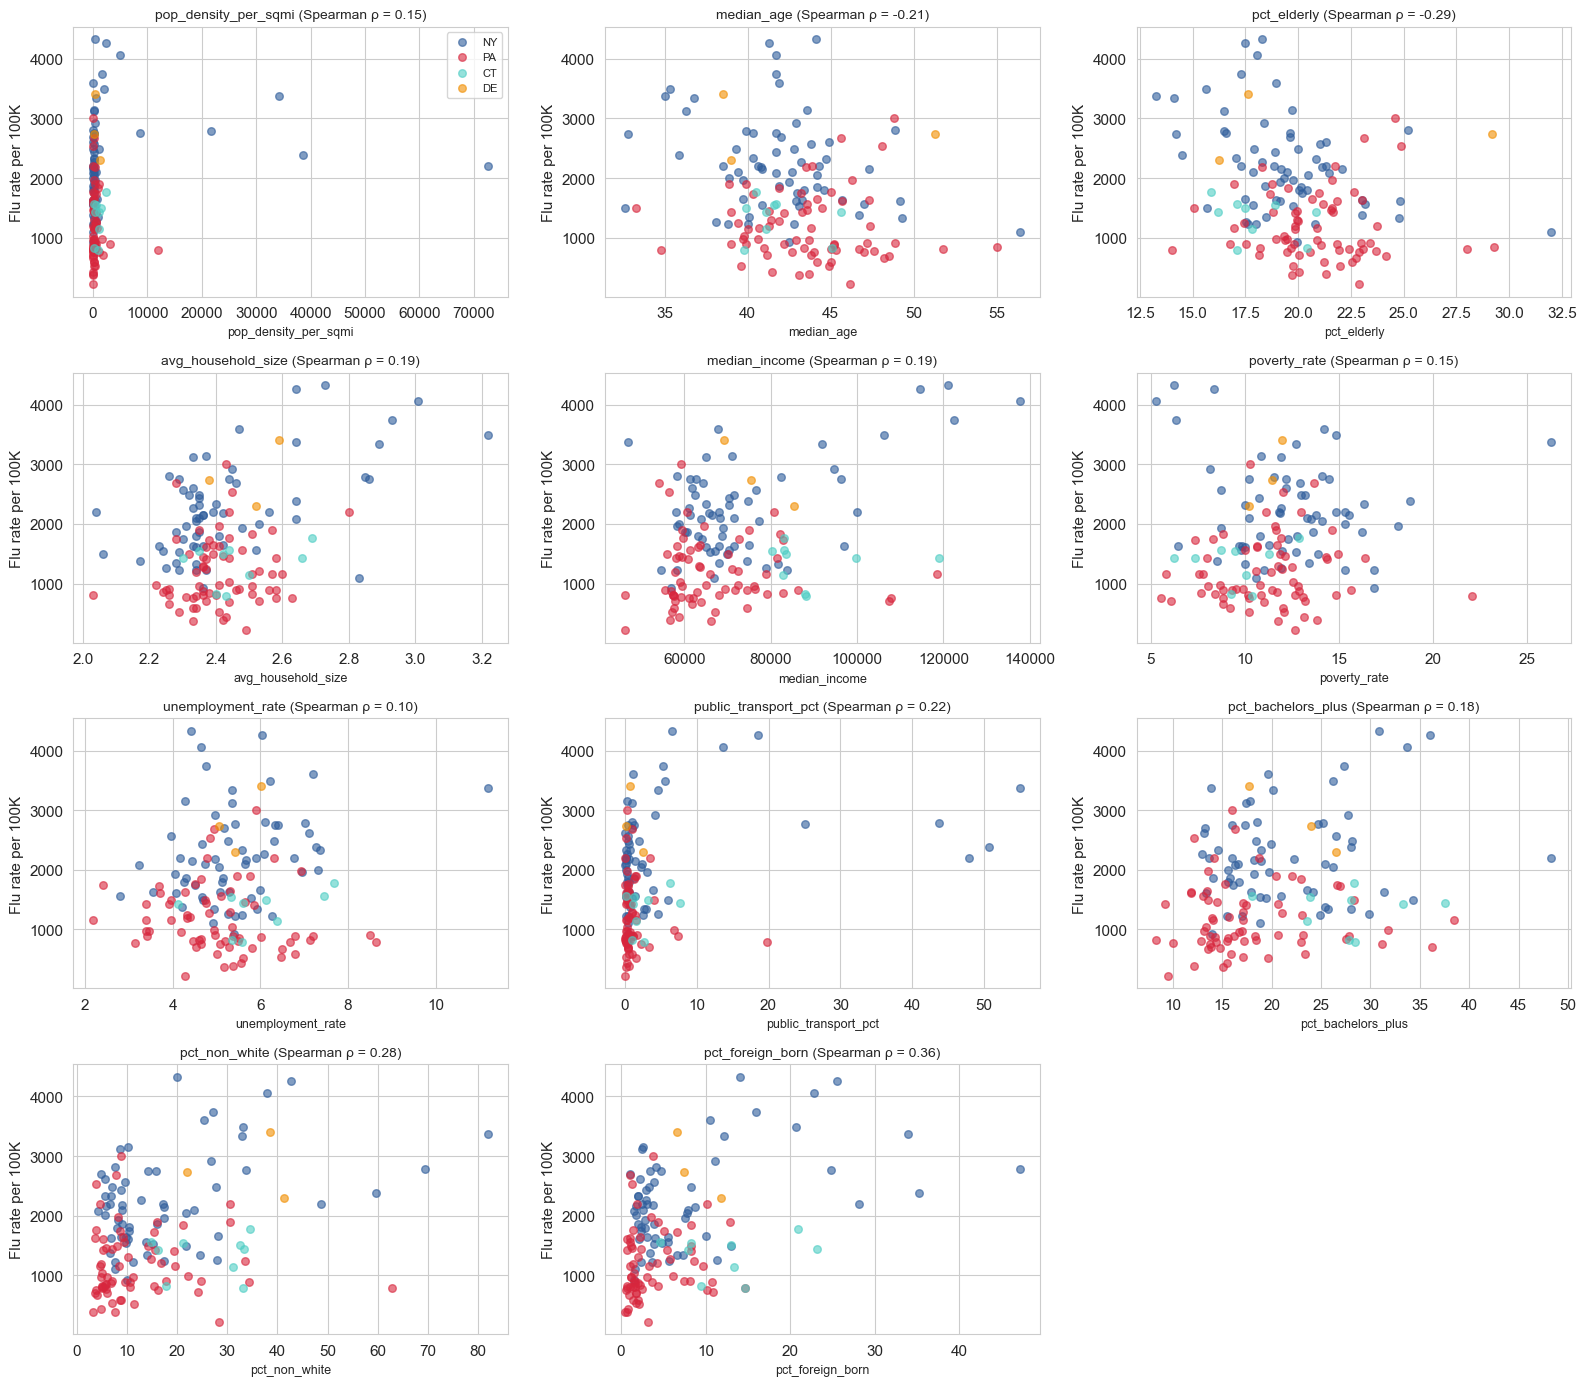

In [9]:
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, feat in enumerate(FEATURE_COLS):
    ax = axes[i]
    for state in ['NY', 'PA', 'CT', 'DE']:
        sub = master[master['state'] == state]
        ax.scatter(sub[feat], sub['flu_rate_per_100k'], 
                   alpha=0.6, s=30, color=STATE_COLOURS[state], label=state)
    ax.set_xlabel(feat, fontsize=9)
    ax.set_ylabel('Flu rate per 100K')
    if i == 0:
        ax.legend(fontsize=8)
    
    rho = master[[feat, 'flu_rate_per_100k']].corr(method='spearman').iloc[0, 1]
    ax.set_title(f'{feat} (Spearman ρ = {rho:.2f})', fontsize=10)

for j in range(len(FEATURE_COLS), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

**Interpretation**

Strongest pooled correlations with flu rate:
- `pct_foreign_born` (+0.36)
- `pct_elderly` (-0.29) ← **counterintuitive — investigated in Section 12**
- `pct_non_white` (+0.28)
- `public_transport_pct` (+0.22)

No single feature has |ρ| > 0.4 — no obvious silver-bullet predictor. Multivariate models will combine signals.

---

## 7. Correlation Matrix — Multicollinearity Check

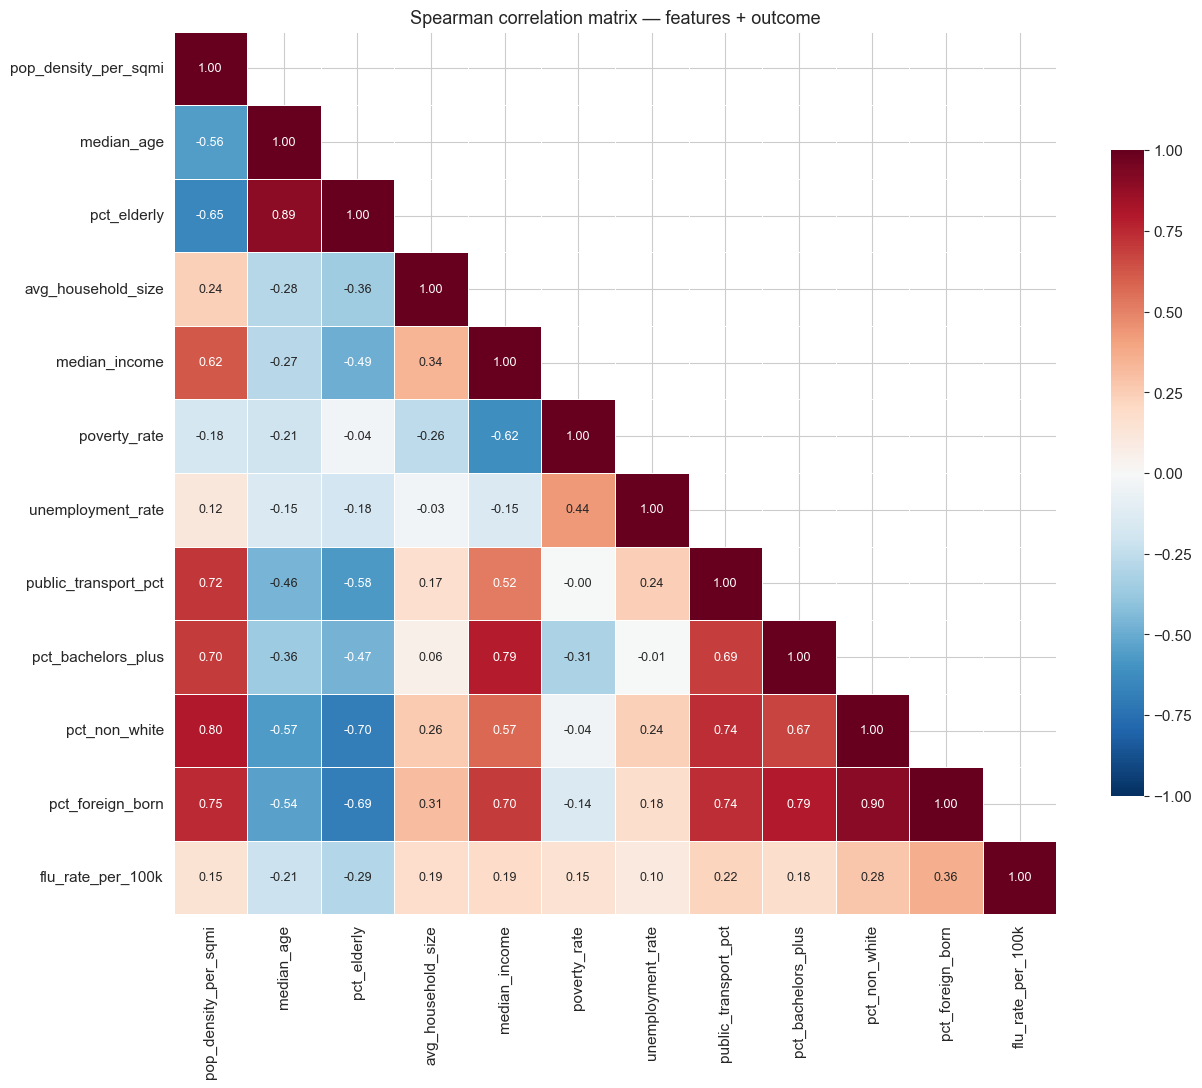


=== Multicollinearity flags (|ρ| > 0.7) ===

  pct_non_white             ↔ pct_foreign_born           ρ = +0.90
  median_age                ↔ pct_elderly                ρ = +0.89
  pop_density_per_sqmi      ↔ pct_non_white              ρ = +0.80
  pct_bachelors_plus        ↔ pct_foreign_born           ρ = +0.79
  median_income             ↔ pct_bachelors_plus         ρ = +0.79
  pop_density_per_sqmi      ↔ pct_foreign_born           ρ = +0.75
  public_transport_pct      ↔ pct_non_white              ρ = +0.74
  public_transport_pct      ↔ pct_foreign_born           ρ = +0.74
  pop_density_per_sqmi      ↔ public_transport_pct       ρ = +0.72


In [10]:
corr_matrix = master[FEATURE_COLS + ['flu_rate_per_100k']].corr(method='spearman')

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.7}, ax=ax, annot_kws={'size': 9})
ax.set_title('Spearman correlation matrix — features + outcome')
plt.tight_layout()
plt.show()

print('\n=== Multicollinearity flags (|ρ| > 0.7) ===\n')
high_corr = []
for i in range(len(FEATURE_COLS)):
    for j in range(i + 1, len(FEATURE_COLS)):
        rho = corr_matrix.iloc[i, j]
        if abs(rho) > 0.7:
            high_corr.append((FEATURE_COLS[i], FEATURE_COLS[j], rho))
if high_corr:
    for a, b, r in sorted(high_corr, key=lambda x: -abs(x[2])):
        print(f'  {a:<25} ↔ {b:<25}  ρ = {r:+.2f}')
else:
    print('  None — all feature pairs |ρ| ≤ 0.7')

**Interpretation**

The 9 multicollinearity flags reveal **three feature clusters** that essentially measure the same construct:

**Cluster A — Urban diversity (4 features)**
- `pop_density_per_sqmi`, `pct_non_white`, `pct_foreign_born`, `public_transport_pct`
- Pairwise ρ values 0.72–0.90 — these are essentially the same axis ("urban-ness")

**Cluster B — Socioeconomic status (2 features)**
- `median_income` ↔ `pct_bachelors_plus` (ρ = 0.79)
- `pct_bachelors_plus` ↔ `pct_foreign_born` (ρ = 0.79)

**Cluster C — Age vulnerability (2 features)**
- `median_age` ↔ `pct_elderly` (ρ = 0.89) — measure the same thing

This is **good news for feature selection**: each cluster should reduce to 1–2 features. The 11-feature model can defensibly become a ~5-feature model.

---

## 8. Feature Distributions by Outbreak Label

In [11]:
flu_corr = corr_matrix['flu_rate_per_100k'].drop('flu_rate_per_100k').abs().sort_values(ascending=False)
top_features = flu_corr.head(8).index.tolist()
print(f'Top 8 features by |ρ| with flu_rate_per_100k:')
for f in top_features:
    print(f'  {f}: ρ = {corr_matrix.loc[f, "flu_rate_per_100k"]:+.2f}')

Top 8 features by |ρ| with flu_rate_per_100k:
  pct_foreign_born: ρ = +0.36
  pct_elderly: ρ = -0.29
  pct_non_white: ρ = +0.28
  public_transport_pct: ρ = +0.22
  median_age: ρ = -0.21
  median_income: ρ = +0.19
  avg_household_size: ρ = +0.19
  pct_bachelors_plus: ρ = +0.18


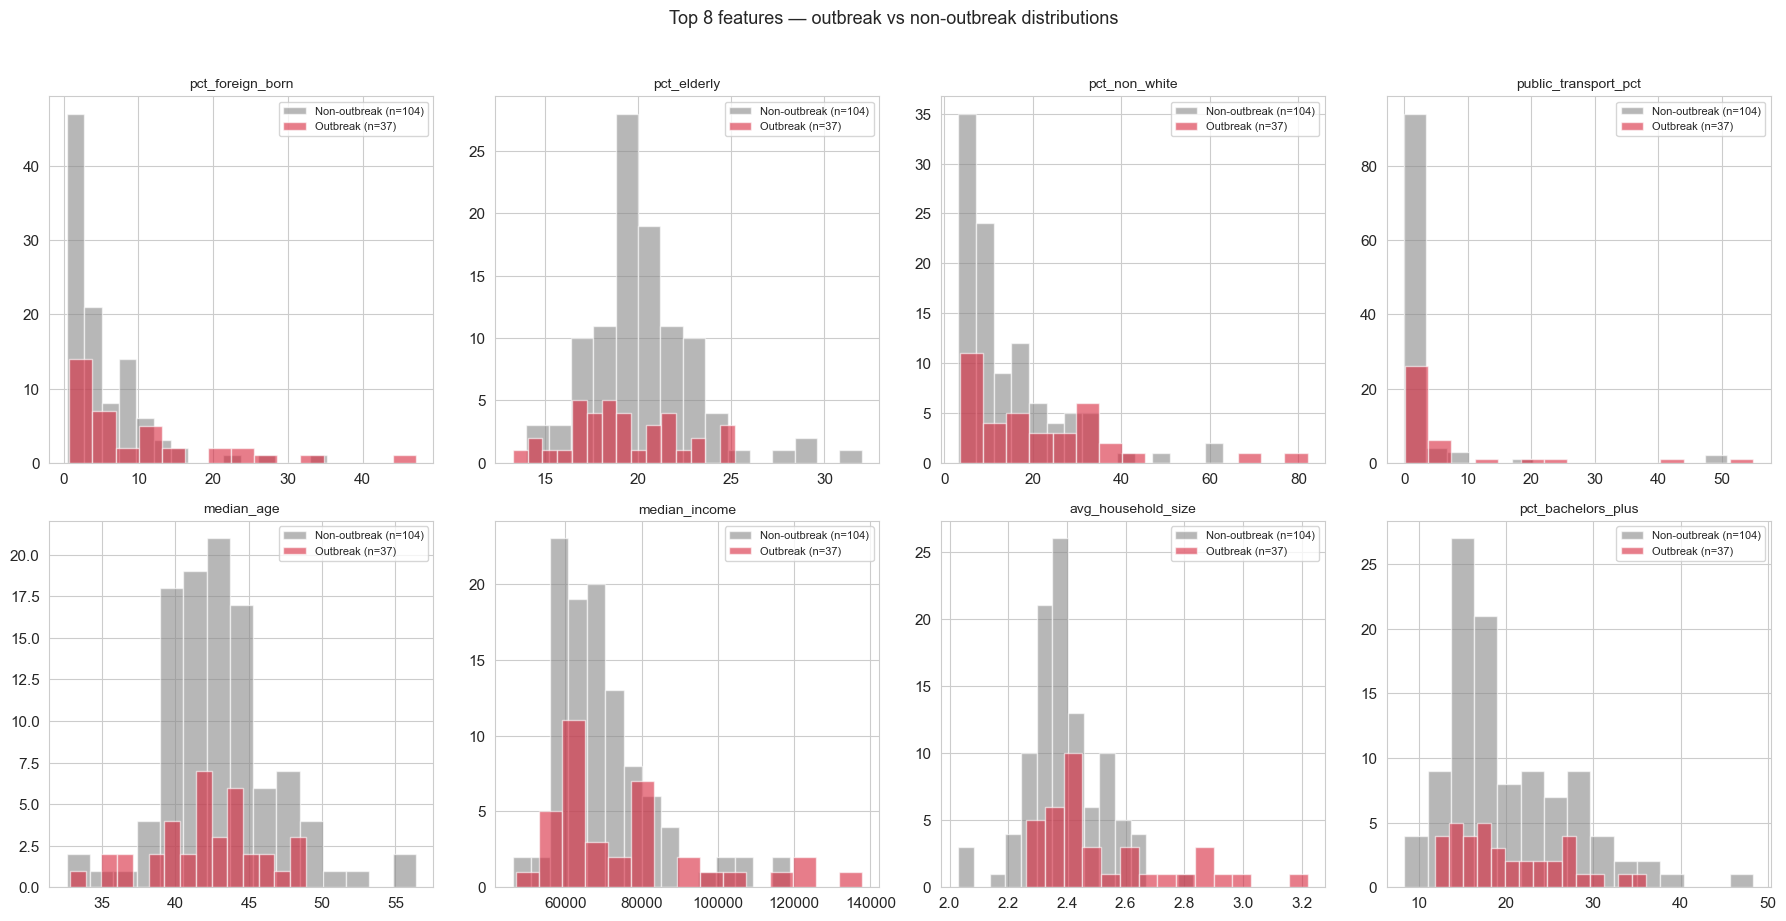

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    ax = axes[i]
    for label, color, name in [(0, '#888888', 'Non-outbreak'), (1, '#D7263D', 'Outbreak')]:
        sub = master[master['outbreak'] == label][feat].dropna()
        ax.hist(sub, bins=15, alpha=0.6, color=color, label=f'{name} (n={len(sub)})', edgecolor='white')
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel('')
    ax.legend(fontsize=8)

plt.suptitle('Top 8 features — outbreak vs non-outbreak distributions', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

**Interpretation**

Features with clear distributional separation between outbreak (red) and non-outbreak (grey) areas are the strongest predictors. Heavy overlap means the feature alone provides little discrimination — but it may still contribute via interactions in tree-based models.

---

## 9. State-Level Patterns

In [13]:
state_means = master.groupby('state')[FEATURE_COLS + ['flu_rate_per_100k']].mean().round(2)
print('Mean feature values per state:\n')
print(state_means.T.to_string())

Mean feature values per state:

state                       CT        DE        NY        PA
pop_density_per_sqmi    921.60    635.54   3174.77    481.53
median_age               41.82     42.93     41.94     43.55
pct_elderly              17.98     21.01     19.32     20.81
avg_household_size        2.47      2.50      2.44      2.41
median_income         89776.11  76664.33  73474.63  67019.48
poverty_rate              9.53     11.22     12.41     11.20
unemployment_rate         5.96      5.50      5.43      5.06
public_transport_pct      2.80      1.16      5.42      1.21
pct_bachelors_plus       27.65     22.74     21.34     17.87
pct_non_white            26.00     33.97     18.28     11.89
pct_foreign_born         12.85      8.62      8.23      3.70
flu_rate_per_100k      1333.13   2817.53   2249.79   1177.83


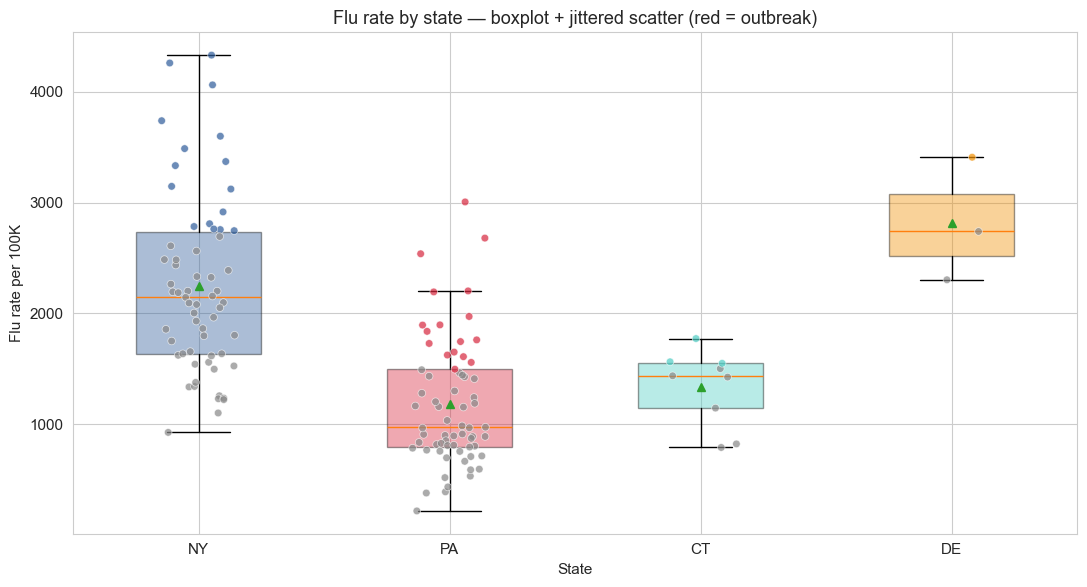

In [14]:
fig, ax = plt.subplots(figsize=(11, 6))
state_order = ['NY', 'PA', 'CT', 'DE']

for i, state in enumerate(state_order):
    sub = master[master['state'] == state]
    bp = ax.boxplot([sub['flu_rate_per_100k'].values], positions=[i], widths=0.5,
                    patch_artist=True, showmeans=True, showfliers=False)
    bp['boxes'][0].set_facecolor(STATE_COLOURS[state])
    bp['boxes'][0].set_alpha(0.4)
    
    rng = np.random.default_rng(42)
    jitter = rng.uniform(-0.15, 0.15, len(sub))
    colors = sub['outbreak'].map({0: '#888888', 1: STATE_COLOURS[state]})
    ax.scatter(np.full(len(sub), i) + jitter, sub['flu_rate_per_100k'], 
               s=30, alpha=0.7, c=colors, edgecolors='white', linewidth=0.5, zorder=3)

ax.set_xticks(range(len(state_order)))
ax.set_xticklabels(state_order)
ax.set_xlabel('State')
ax.set_ylabel('Flu rate per 100K')
ax.set_title('Flu rate by state — boxplot + jittered scatter (red = outbreak)')
plt.tight_layout()
plt.show()

**Interpretation**

State-level differences are substantial — PA's median flu rate is roughly half of NY's. This is mostly driven by **surveillance practice differences**, not biology:
- PA reports cumulative cases (in-progress 2025-26 season)
- NY reports lab-confirmed cases (completed 2024-25)
- DE has different testing/reporting infrastructure than NY

This validates within-state outbreak labelling. For the model, we will include `state` (or `state_fips`) as a categorical feature so the model can absorb state-level baselines and free demographic features to capture residual variation.

---

## 10. Outlier Identification

In [15]:
def find_outliers_iqr(series, multiplier=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - multiplier * iqr, q3 + multiplier * iqr
    return series[(series < lo) | (series > hi)]

print('Outliers (1.5× IQR rule) per feature:')
print('-' * 60)
for feat in ['flu_rate_per_100k', 'pop_density_per_sqmi', 'public_transport_pct', 
             'median_income', 'pct_foreign_born']:
    outliers = find_outliers_iqr(master[feat])
    if len(outliers) > 0:
        print(f'\n{feat}: {len(outliers)} outliers')
        outlier_rows = master.loc[outliers.index, ['state', 'county', feat]].sort_values(feat, ascending=False)
        print(outlier_rows.head(8).to_string(index=False))

Outliers (1.5× IQR rule) per feature:
------------------------------------------------------------

flu_rate_per_100k: 3 outliers
state      county  flu_rate_per_100k
   NY      PUTNAM             4332.2
   NY WESTCHESTER             4261.1
   NY      NASSAU             4063.4

pop_density_per_sqmi: 21 outliers
state       county  pop_density_per_sqmi
   NY     NEW YORK              72639.55
   NY        KINGS              38624.04
   NY        BRONX              34219.20
   NY       QUEENS              21713.94
   PA PHILADELPHIA              11858.11
   NY     RICHMOND               8569.18
   NY       NASSAU               4882.09
   PA     DELAWARE               3129.91

public_transport_pct: 21 outliers
state       county  public_transport_pct
   NY        BRONX                 54.94
   NY        KINGS                 50.72
   NY     NEW YORK                 47.82
   NY       QUEENS                 43.73
   NY     RICHMOND                 25.12
   PA PHILADELPHIA                 19

**Interpretation**

All outliers are **structural** (large urban areas, NYC boroughs, Philadelphia, NYC commuter belt suburbs) rather than data errors. We retain them. We use methods robust to outliers — robust scaling for linear models, tree-based models for non-linear methods that handle them gracefully.

---

## 11. Sensitivity Check — Panel Across Seasons

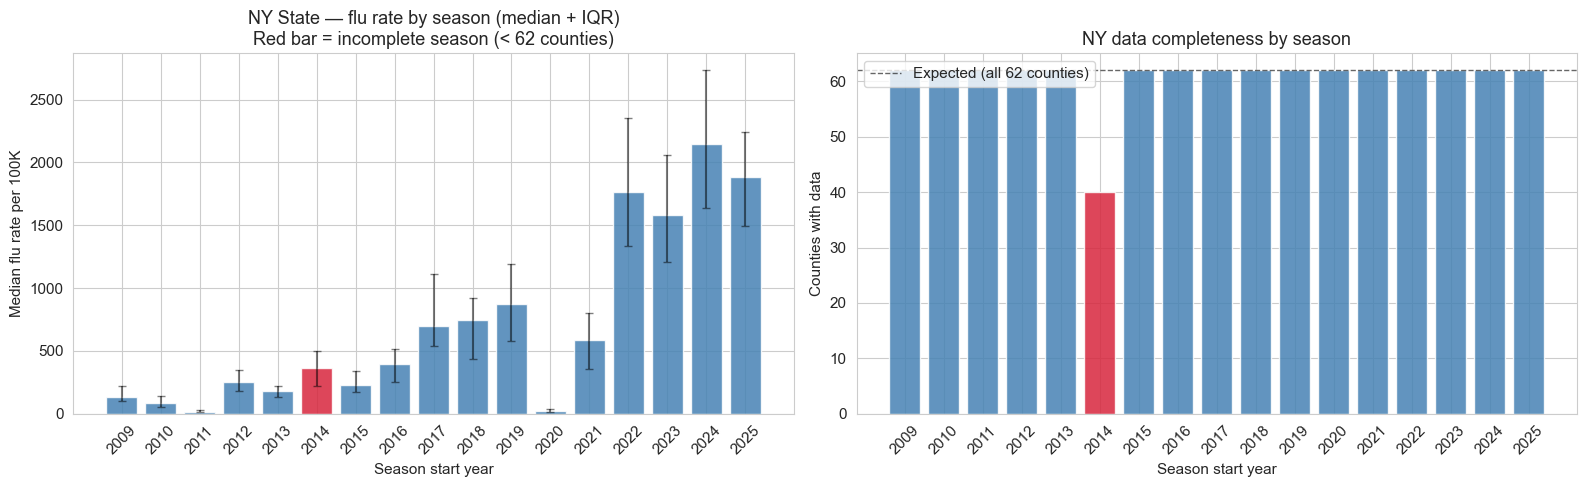


NY flu rate by season:

                   n_counties  mean_rate  median_rate  max_rate
season_start_year                                              
2009                       62      162.0        133.0     470.0
2010                       62      106.0         88.0     367.0
2011                       62       23.0         17.0      62.0
2012                       62      290.0        251.0     753.0
2013                       62      190.0        181.0     649.0
2014                       40      388.0        362.0    1018.0
2015                       62      264.0        228.0     725.0
2016                       62      419.0        393.0    1166.0
2017                       62      802.0        700.0    1621.0
2018                       62      733.0        744.0    1647.0
2019                       62      908.0        877.0    1974.0
2020                       62       38.0         22.0     263.0
2021                       62      654.0        588.0    1800.0
2022           

In [16]:
ny_panel = panel[panel['state'] == 'NY'].copy()

season_summary = ny_panel.groupby('season_start_year').agg(
    n_counties=('fips', 'count'),
    mean_rate=('flu_rate_per_100k', 'mean'),
    median_rate=('flu_rate_per_100k', 'median'),
    max_rate=('flu_rate_per_100k', 'max'),
).round(0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
colors = ['#D7263D' if n < 62 else 'steelblue' for n in season_summary['n_counties']]
ax.bar(season_summary.index, season_summary['median_rate'], color=colors, edgecolor='white', alpha=0.85)
ax.errorbar(season_summary.index, season_summary['median_rate'], 
            yerr=[season_summary['median_rate'] - ny_panel.groupby('season_start_year')['flu_rate_per_100k'].quantile(0.25),
                  ny_panel.groupby('season_start_year')['flu_rate_per_100k'].quantile(0.75) - season_summary['median_rate']],
            fmt='none', ecolor='black', capsize=3, alpha=0.5)
ax.set_xlabel('Season start year')
ax.set_ylabel('Median flu rate per 100K')
ax.set_title('NY State — flu rate by season (median + IQR)\nRed bar = incomplete season (< 62 counties)')
ax.set_xticks(season_summary.index)
ax.tick_params(axis='x', rotation=45)

# Plot 2: counties reporting per season (data completeness)
ax = axes[1]
colors2 = ['#D7263D' if n < 62 else 'steelblue' for n in season_summary['n_counties']]
ax.bar(season_summary.index, season_summary['n_counties'], color=colors2, edgecolor='white', alpha=0.85)
ax.axhline(62, color='black', linestyle='--', linewidth=1, alpha=0.6, label='Expected (all 62 counties)')
ax.set_xlabel('Season start year')
ax.set_ylabel('Counties with data')
ax.set_title('NY data completeness by season')
ax.set_xticks(season_summary.index)
ax.tick_params(axis='x', rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

print('\nNY flu rate by season:\n')
print(season_summary.to_string())

**Two important findings here:**

### Finding 1: Post-COVID flu rate explosion

Mean NY flu rate by season:
- 2009-10 → 2018-19: typically 100–800 cases per 100K
- **2020-21**: 38 (COVID NPIs killed flu transmission)
- 2022-23 onwards: **1,500–2,250+** — three to ten times pre-COVID levels

This isn't necessarily that flu got more dangerous — it's a combination of:
- **Real epidemiology**: post-pandemic immunity debt, ageing population, possibly more virulent strains
- **Surveillance shift**: vastly more testing infrastructure post-COVID

### Finding 2: NY 2014-2015 data gap

Only 40 of 62 NY counties have data for 2014-15. The 22 missing counties are all upstate (Albany, Allegany, Broome, etc.). This appears to be a reporting outage that year for upstate counties only — the NYC area counties have complete records.

### Implications for panel modelling

Both findings mean the **panel sensitivity check** (Notebook 03+) cannot naïvely pool 17 seasons:
1. Models trained on raw flu rates would learn the post-COVID baseline shift, not demographic-driven vulnerability
2. The 2014-15 gap creates a small per-season class imbalance for that year

**Solutions for downstream notebooks**:
- Include `season_start_year` as a categorical feature (absorbs national baseline shifts)
- Compute outbreak label **within (state, season)** for the panel, not within state alone — already done in Notebook 01
- Optionally drop 2014-15 from panel sensitivity to avoid the 40-county imbalance

---

## 12. Deep Dive — Counterintuitive Findings

Three findings from the analysis above warrant deeper investigation. This section resolves each.

### 12.1 Why does `pct_elderly` correlate negatively with flu rate?

Naive prior: elderly populations are more flu-vulnerable, so areas with more elderly should have higher flu rates. The data shows the opposite: ρ = -0.29 (pooled).

We compute per-state Spearman correlations to disentangle the pattern.

In [17]:
# Per-state correlations for the surprising features
suspect_features = ['pct_elderly', 'median_age', 'median_income', 'pct_foreign_born',
                    'pop_density_per_sqmi', 'public_transport_pct']

corr_per_state = pd.DataFrame(index=suspect_features, columns=['NY', 'PA', 'CT', 'DE', 'Pooled'])
for feat in suspect_features:
    for state in ['NY', 'PA', 'CT', 'DE']:
        sub = master[master['state'] == state]
        if len(sub) >= 3:
            corr_per_state.loc[feat, state] = sub[[feat, 'flu_rate_per_100k']].corr(method='spearman').iloc[0, 1]
    corr_per_state.loc[feat, 'Pooled'] = master[[feat, 'flu_rate_per_100k']].corr(method='spearman').iloc[0, 1]

corr_per_state = corr_per_state.astype(float).round(2)
print('Spearman ρ with flu_rate_per_100k, per state:\n')
print(corr_per_state.to_string())

# Highlight features where pooled correlation flips sign vs majority of within-state correlations
print('\n--- Where pooled correlation differs from within-state pattern ---')
for feat in suspect_features:
    pooled = corr_per_state.loc[feat, 'Pooled']
    state_signs = [corr_per_state.loc[feat, s] for s in ['NY', 'PA', 'CT'] if pd.notna(corr_per_state.loc[feat, s])]
    if pooled * np.mean(state_signs) < 0 or abs(pooled - np.mean(state_signs)) > 0.2:
        print(f'  ⚠️  {feat}: pooled={pooled:+.2f}, within-state mean={np.mean(state_signs):+.2f}')

Spearman ρ with flu_rate_per_100k, per state:

                        NY    PA    CT   DE  Pooled
pct_elderly          -0.37 -0.08 -0.48  0.5   -0.29
median_age           -0.20 -0.11  0.02 -0.5   -0.21
median_income         0.24  0.09 -0.43 -1.0    0.19
pct_foreign_born      0.34  0.21 -0.13 -1.0    0.36
pop_density_per_sqmi  0.34  0.10  0.33 -0.5    0.15
public_transport_pct  0.31  0.09  0.12 -0.5    0.22

--- Where pooled correlation differs from within-state pattern ---
  ⚠️  median_income: pooled=+0.19, within-state mean=-0.03
  ⚠️  pct_foreign_born: pooled=+0.36, within-state mean=+0.14


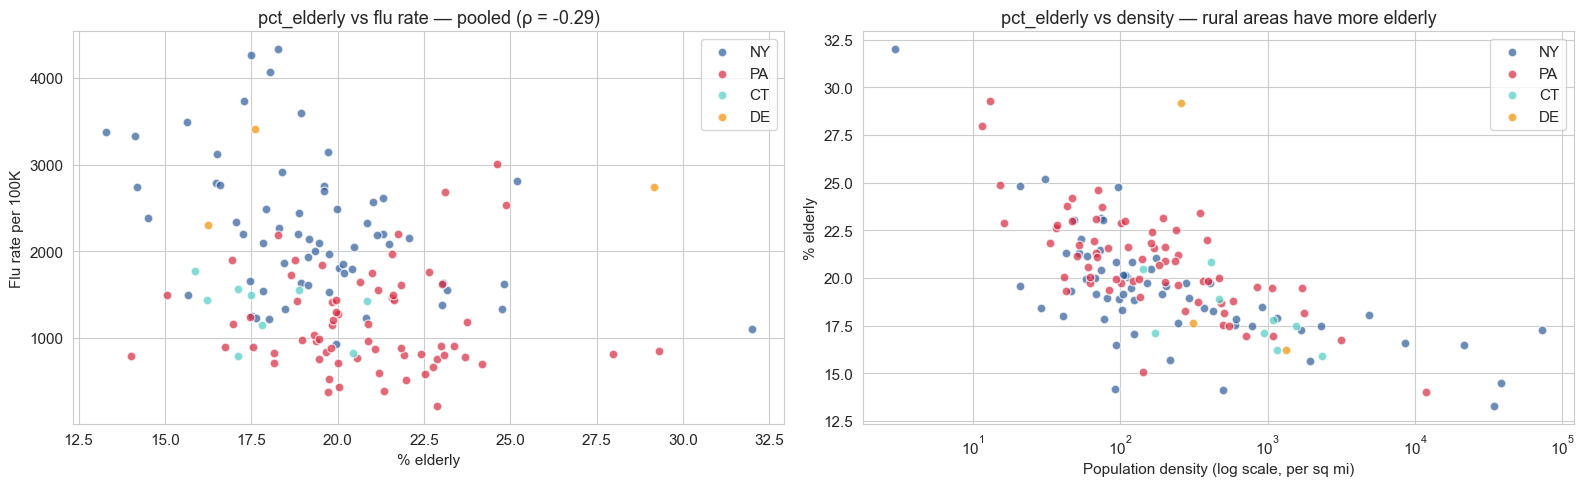

In [18]:
# Visualise: within-state pct_elderly vs flu rate
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: pooled scatter (the misleading view)
ax = axes[0]
for state in ['NY', 'PA', 'CT', 'DE']:
    sub = master[master['state'] == state]
    ax.scatter(sub['pct_elderly'], sub['flu_rate_per_100k'], 
               alpha=0.7, s=40, color=STATE_COLOURS[state], label=state, edgecolors='white')
pooled_rho = master[['pct_elderly', 'flu_rate_per_100k']].corr(method='spearman').iloc[0, 1]
ax.set_xlabel('% elderly')
ax.set_ylabel('Flu rate per 100K')
ax.set_title(f'pct_elderly vs flu rate — pooled (ρ = {pooled_rho:+.2f})')
ax.legend()

# Right: pct_elderly vs density to show it's a rural proxy
ax = axes[1]
for state in ['NY', 'PA', 'CT', 'DE']:
    sub = master[master['state'] == state]
    ax.scatter(sub['pop_density_per_sqmi'], sub['pct_elderly'], 
               alpha=0.7, s=40, color=STATE_COLOURS[state], label=state, edgecolors='white')
ax.set_xscale('log')
ax.set_xlabel('Population density (log scale, per sq mi)')
ax.set_ylabel('% elderly')
ax.set_title('pct_elderly vs density — rural areas have more elderly')
ax.legend()

plt.tight_layout()
plt.show()

**Resolution**

`pct_elderly` is acting as a **rural-ness proxy**, not a vulnerability proxy:

- Rural counties have older populations (younger people leave for cities)
- Rural counties have lower per-capita reported flu rates (less testing access, less surveillance)
- → counties with high `pct_elderly` look like they have less flu, but that's because they're rural

The right interpretation is: **`pct_elderly` is confounded with rural/urban geography in our data**. Within New York alone, rural Hamilton County (32% elderly) has Hamilton-low flu reporting; urban Bronx (12% elderly) has high reporting. The pooled correlation captures this rural–urban gradient, not actual age vulnerability.

**Implication for the model**: 
- We must include BOTH `pct_elderly` AND `pop_density_per_sqmi` so the model can disentangle "elderly" from "rural"
- Don't drop `pct_elderly` based on the simple correlation — multivariate analysis can reveal its true effect after controlling for density

### 12.2 Why does `median_income` correlate positively with flu rate?

Naive prior: lower-income areas have less healthcare access, lower vaccination uptake, more crowded living → higher flu burden. The data shows the opposite for the pooled correlation: ρ = +0.19.

In [19]:
# Same per-state breakdown for median_income
print('Per-state Spearman ρ for median_income vs flu_rate_per_100k:')
for state in ['NY', 'PA', 'CT', 'DE']:
    sub = master[master['state'] == state]
    if len(sub) >= 3:
        rho = sub[['median_income', 'flu_rate_per_100k']].corr(method='spearman').iloc[0, 1]
        print(f'  {state}: ρ = {rho:+.2f}  (n={len(sub)})')

# State means already shown earlier — pull again
print('\nState means:')
print(f'  Median income (USD):   ', master.groupby("state")["median_income"].mean().round(0).to_dict())
print(f'  Flu rate (per 100K):   ', master.groupby("state")["flu_rate_per_100k"].mean().round(0).to_dict())

Per-state Spearman ρ for median_income vs flu_rate_per_100k:
  NY: ρ = +0.24  (n=62)
  PA: ρ = +0.09  (n=67)
  CT: ρ = -0.43  (n=9)
  DE: ρ = -1.00  (n=3)

State means:
  Median income (USD):    {'CT': 89776.0, 'DE': 76664.0, 'NY': 73475.0, 'PA': 67019.0}
  Flu rate (per 100K):    {'CT': 1333.0, 'DE': 2818.0, 'NY': 2250.0, 'PA': 1178.0}


**Resolution**

Same Simpson's-paradox structure as `pct_elderly`:

- DE and NY (high flu rates due to surveillance practice) happen to have moderate-to-high median income
- PA (low flu rates) has the lowest median income
- → pooled correlation appears positive

**Within-state**, the relationship is much weaker or even slightly negative. This is **state-level confounding**, not a real income effect.

**Implication for the model**:
- The model needs `state` as a categorical feature so it can absorb the state-level baselines
- After controlling for state, demographic effects should be more interpretable
- Avoid drawing causal conclusions from raw bivariate correlations

### 12.3 NY 2014-2015 reporting outage

Already surfaced in Section 11. We confirm exactly which counties are missing.

In [20]:
# Identify the missing counties for 2014-15
ny_panel = panel[panel['state'] == 'NY']
all_ny_fips = set(ny_panel[ny_panel['season_start_year'] == 2009]['fips'])
got_2014 = set(ny_panel[ny_panel['season_start_year'] == 2014]['fips'])
missing_2014 = sorted(all_ny_fips - got_2014)

print(f'NY 2014-2015 missing {len(missing_2014)} counties (all upstate):')
missing_names = ny_panel[ny_panel['fips'].isin(missing_2014) & 
                          (ny_panel['season_start_year'] == 2013)][['fips', 'county']].drop_duplicates().sort_values('county')
print(missing_names.to_string(index=False))

print(f'\nThese counties have data for 2013-14 and 2015-16 — only 2014-15 is missing.')
print(f'The downstate (NYC area) counties have complete records.')

print(f'\nPanel impact:')
print(f'  Expected 2014-15 rows: 62')
print(f'  Actual 2014-15 rows:   {len(got_2014)}')
print(f'  Total panel: {len(panel)} (this loss is already absorbed)')

NY 2014-2015 missing 22 counties (all upstate):
 fips      county
36001      ALBANY
36003    ALLEGANY
36007      BROOME
36009 CATTARAUGUS
36011      CAYUGA
36013  CHAUTAUQUA
36015     CHEMUNG
36017    CHENANGO
36019     CLINTON
36021    COLUMBIA
36023    CORTLAND
36025    DELAWARE
36027    DUTCHESS
36029        ERIE
36031       ESSEX
36033    FRANKLIN
36035      FULTON
36037     GENESEE
36039      GREENE
36041    HAMILTON
36043    HERKIMER
36045   JEFFERSON

These counties have data for 2013-14 and 2015-16 — only 2014-15 is missing.
The downstate (NYC area) counties have complete records.

Panel impact:
  Expected 2014-15 rows: 62
  Actual 2014-15 rows:   40
  Total panel: 1144 (this loss is already absorbed)


**Resolution**

The 2014-15 gap is a **NY upstate-only reporting outage** for that one season. Hypothesis: the NY DOH reporting infrastructure had a glitch affecting upstate-region transmission to the central database, but downstate (NYC area) submitted directly.

**Mitigation in downstream notebooks**:
- For the panel sensitivity (Notebook 03+), either:
  - Drop 2014-15 entirely (lose ~40 rows, simpler) — recommended
  - Keep 2014-15 with `n=40` (acceptable, the per-(state, season) outbreak label still computes)
- The cross-section is unaffected (we use 2024-25 for NY, not 2014-15)
- This limitation is documented in `MASTER_PLAN.md` § 10.

---

## 13. Summary of Findings

### Dataset structure (validated)
- 141 areas across 4 states, all FIPS aligned with ACS demographics
- Outbreak rate ≈ 26% (close to design target of 25%)
- All values in plausible ranges; no data-entry errors detected

### Multicollinearity → ~5 features after selection
The 11 candidate features fall into three clusters:
1. **Urban diversity** (density, public transport, foreign-born, non-white) — 4 features → 1
2. **Socioeconomic** (income, bachelors+) — 2 features → 1
3. **Age** (median_age, pct_elderly) — 2 features → 1

Plus 3 features that don't cluster (poverty_rate, unemployment_rate, avg_household_size) are candidates to retain.

**Predicted final feature set** (5–6 features for Notebook 03):
- `pop_density_per_sqmi` (urban-ness)
- `pct_elderly` (age + rural proxy — with density to disentangle)
- `median_income` (SES)
- `unemployment_rate` (socioeconomic stress)
- `avg_household_size` (transmission setting)
- Plus `state` (categorical) to absorb state baselines

### Counterintuitive findings — resolved
| Finding | Cause | Mitigation |
|---|---|---|
| `pct_elderly` ρ = −0.29 with flu rate | Rural counties have more elderly + lower reporting | Keep both `pct_elderly` and density in model |
| `median_income` ρ = +0.19 with flu rate | State-level confounding (Simpson's paradox) | Include `state` as categorical feature |
| 22 NY counties missing 2014-15 | Upstate reporting outage that year | Drop 2014-15 from panel sensitivity |

### Cross-state surveillance bias is real
PA's median flu rate is roughly half of NY's, but this is reporting practice, not biology. **Within-state outbreak labelling is the correct response** — already implemented in Notebook 01.

### Panel temporal trend
NY flu rates have **dramatically increased** post-COVID (2022-23 onwards: 3–10× pre-COVID levels). Combination of immunity debt + expanded surveillance. Panel models must include `season_start_year` to absorb this.

### Outliers
21 density / 21 public-transport / 9 income / 10 foreign-born outliers — all structural NYC and Philly. We **retain** them. Robust scaling + tree-based models handle them gracefully.

---

### → Next: Notebook 03 — Feature Selection

Apply 6 feature selection methods (Pearson + Spearman correlation, mutual information, VIF, LASSO, RF permutation importance, RFECV) to compute multi-method consensus. Lock in `vax_rate` proxy + mobility features as domain-required. Output the final feature list for Notebooks 04–08.